In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from scipy.constants import mu_0, epsilon_0
from scipy import fftpack
from scipy import sparse
from scipy.special import factorial
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d, CubicSpline, BSpline
from scipy.sparse import csr_matrix, csc_matrix
import csv
from scipy.special import roots_legendre, eval_legendre
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import lu_factor, lu_solve
from scipy import signal
import ipywidgets
import discretize
import  os
import json
from PIL import Image
import seaborn as sns
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import ipywidgets as widgets
eps = np.finfo(float).eps

In [2]:
import empymod
from masa_utils import PsuedoLog
from masa_utils import Pelton_res_f
from masa_utils import InducedPolarizationSimulation 
from masa_utils import Optimization 
from masa_utils import empymod_IP_simulation
from masa_utils import TEM_Signal_Process


Simulatin and synthetic study on deep sea hydrothermal deposits explortaion using WISTEM (K. Nakayama and A. Saito, 2016) (K.Nakayama M. Motoori and A. Saito,2019). On-Time: 200msec ramp time: 200usec Transmitter Loop: 3.5m Square Loop Receiver Loop: Coincident-type Number of Turn: 5 3.5m rectangular loop has equivalent area for 2.0m circular loop.

In [3]:
base_freq=1.25
on_time=0.2
rmp_time=200e-6
rec_time=3e-2
smp_freq=50e3 #200e3  

In [4]:
tx_side = 3.5
tx_radius = (tx_side)/(np.sqrt(np.pi))
tx_circumeference = 2*np.pi*tx_radius
tx_surface = np.pi*tx_radius**2
n_turns = 5
tx_depth = 0
print(f"Transmitter radius: {tx_radius}")

Transmitter radius: 1.9746635424171473


In [5]:
tstrt, tend = 1e-4, 3e-2
logstep = 1/15
WISTEM_SP_sim = TEM_Signal_Process(
    base_freq=base_freq,
    on_time=on_time, 
    rmp_time=rmp_time, 
    rec_time=tend, 
    smp_freq=smp_freq*4
)


In [6]:
times_sim = WISTEM_SP_sim.times_rec
times_clc = WISTEM_SP_sim.times_rec
ntimes = len(times_clc)
print(ntimes)
print(times_clc[:3], times_clc[-3:])
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
windows_strt = WISTEM_SP_sim.windows_strt
windows_cen = WISTEM_SP_sim.windows_cen
windows_end = WISTEM_SP_sim.windows_end
print(windows_cen-rmp_time)

6000
[5.0e-06 1.0e-05 1.5e-05] [0.02999  0.029995 0.03    ]
[0.0001     0.00011659 0.00013594 0.00015849 0.00018478 0.00021544
 0.00025119 0.00029286 0.00034145 0.00039811 0.00046416 0.00054117
 0.00063096 0.00073564 0.0008577  0.001      0.00116591 0.00135936
 0.00158489 0.00184785 0.00215443 0.00251189 0.00292864 0.00341455
 0.00398107 0.00464159 0.0054117  0.00630957 0.00735642 0.00857696
 0.01       0.01165914 0.01359356 0.01584893 0.0184785  0.02154435
 0.02511886 0.02928645]


In [7]:
nlayer =1
# csx, csz = tx_radius/4.,tx_radius/4.
res0_target = 0.3
con_target = 1/res0_target
eta_sea , eta_base = 0.,0.
eta_target = 0.6
con8_target = con_target/(1-eta_target)
c_target = 0.4#0.20
thick_target = 10.
tau_pl = 1.0 # 1e-2
tau_cc = tau_pl*((1-eta_target)**(1/c_target))
print(f'tau_cc {tau_cc:.2e}')
print(f'tau_pl {tau_pl:.2e}')

tau_target = tau_pl
print(f'con8 {con8_target:.2e}')
print(f'con  {con_target:.2e}')

res_sea = 0.3
con_sea = 1/res_sea
res_base = 1.0
tau_sea, tau_base, tau_ref = tau_target, tau_target, tau_target #,1.0e-3, 1.0e-3, 1.0e-3
c_sea, c_base, c_ref = c_target, c_target, c_target #0.6,0.6,0.6
res_ref= res_sea
eta_sea , eta_base, eta_ref = 0.,0.,0.1
# thick_ref = 5
depth = np.r_[0, thick_target]
print(f"depth {depth}")
tx_height = 0.3 #csx
print(tx_height)

tau_cc 1.01e-01
tau_pl 1.00e+00
con8 8.33e+00
con  3.33e+00
depth [ 0. 10.]
0.3


In [8]:
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
filt_linrmp = WISTEM_SP_sim.filter_linear_rmp()

Window_mat = WISTEM_SP_sim.get_window_matrix(times_sim)
print(Window_mat.shape)

(38, 6000)


In [9]:
recx, recy = 0 , 0
recBdple = [recx, recy, tx_depth ,0,90]
# recx, recy, recw = rec_area(3, tx_side)
# recBdple = [recx, recy, tx_depth ,0,90]

In [10]:
# emoymod model to simulate WISTEM setting
# Note that it simulate only dBdt field at center of the transmitter loop
# User should multiply by area of the loop to get EMF(V/A)
empymod_model_sim = {
    # simulate each bipole of four side of the transmitter loop
    'src': [ tx_side/2, tx_side/2,  # x1,x2
                     0, tx_side/2,  # y1,y2
             tx_depth, tx_depth], # z1,z2
    # receiver at the center of the transmitter loop
    'rec': recBdple, # [recx, recy, tx_depth ,0,90], # dBzdt at x,y,z,azimuth,dip
    'depth': depth,
#    'res' : res,
    'freqtime': times_sim,
    'signal': 0, # 0: impulse or dBdt, 1: Stepoff or B field
    'msrc' : False, # Electric source
    'mrec' : True, # Magnetic receiver
    'strength': 8.*n_turns* tx_surface * mu_0,  
    'srcpts' : 3,  # Three works for the momtent, maybe worth seeking other number
    'verb': 0, # put 4 for more information
     # Setting xdirect=True can help, as direct field is then computed analytically in f-domain
    'xdirect': True,
}

In [11]:
sim_obs=empymod_IP_simulation(
    model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
    )
sim_obs.deepsea_signle_layer(
    res_sea=res_sea, res_base=res_base,
    eta_sea=eta_sea, tau_sea=tau_sea, c_sea=c_sea,
    eta_base=eta_base, tau_base=tau_base, c_base=c_base 
    )


In [12]:
print(sim_obs.m_fix)
print(sim_obs.model_base)

[-1.2039728  0.         0.         0.         0.         0.
  0.         0.         0.         0.4        0.         0.4      ]
{'src': [1.75, 1.75, 0, 1.75, 0, 0], 'rec': [0, 0, 0, 0, 90], 'depth': array([ 0., 10.]), 'freqtime': array([5.0000e-06, 1.0000e-05, 1.5000e-05, ..., 2.9990e-02, 2.9995e-02,
       3.0000e-02], shape=(6000,)), 'signal': 0, 'msrc': False, 'mrec': True, 'strength': np.float64(0.0006157521600223001), 'srcpts': 3, 'verb': 0, 'xdirect': True}


In [13]:
# res = res_sea * np.ones(nlayer)
# res= np.r_[res0_target,res_base]
m_r = np.log(res0_target)
m = eta_target #* np.ones(nlayer-1)
m_m = m 
m_t = np.log(tau_target) # *np.ones(nlayer-1)
m_c = c_target #*np.ones(nlayer-1)
# m_d = np.log(thick_target)*np.ones(nlayer-1)
mvec_obs = np.r_[m_r, m_m,m_t,m_c]
print(mvec_obs)
print(sim_obs.get_ip_model(mvec_obs))

[-1.2039728  0.6        0.         0.4      ]
{'res': array([0.3, 0.3, 1. ]), 'rho_0': array([0.3, 0.3, 1. ]), 'm': array([0. , 0.6, 0. ]), 'tau': array([1., 1., 1.]), 'c': array([0.4, 0.4, 0.4]), 'func_eta': <bound method empymod_IP_simulation.pelton_et_al of <masa_utils.empymod_IP_simulation object at 0x0000011C92AB9250>>}


In [14]:
dpred_step= sim_obs.dpred(mvec_obs)
sim_obs.cut_off = smp_freq/2.0
print(f"cutoff frequency: {sim_obs.cut_off}")
dpred_LPF = sim_obs.dpred(mvec_obs)
sim_obs.filt_curr = filt_linrmp
dpred_rmp = sim_obs.dpred(mvec_obs)
sim_obs.window_mat=Window_mat
dpred_window = sim_obs.dpred(mvec_obs)

cutoff frequency: 25000.0


In [15]:
PL_decay = PsuedoLog(
    logmin=1e-8,
    linScale=0.5,
    logminx=1e-4,
    linScalex=0.5
    )
PL_jac = PsuedoLog(
    logmin=1e-8,
    linScale=0.2,
    logminx=1e-4,
    linScalex=0.2
    )
PL_jac_Wd = PsuedoLog(
    logmin=1e-1,
    linScale=0.2,
    logminx=1e-4,
    linScalex=0.2
    )
PL_filt = PsuedoLog(
    logmin=1e-7,
    linScale=0.2,
    logminx=1e-4,
    linScalex=0.2
    )

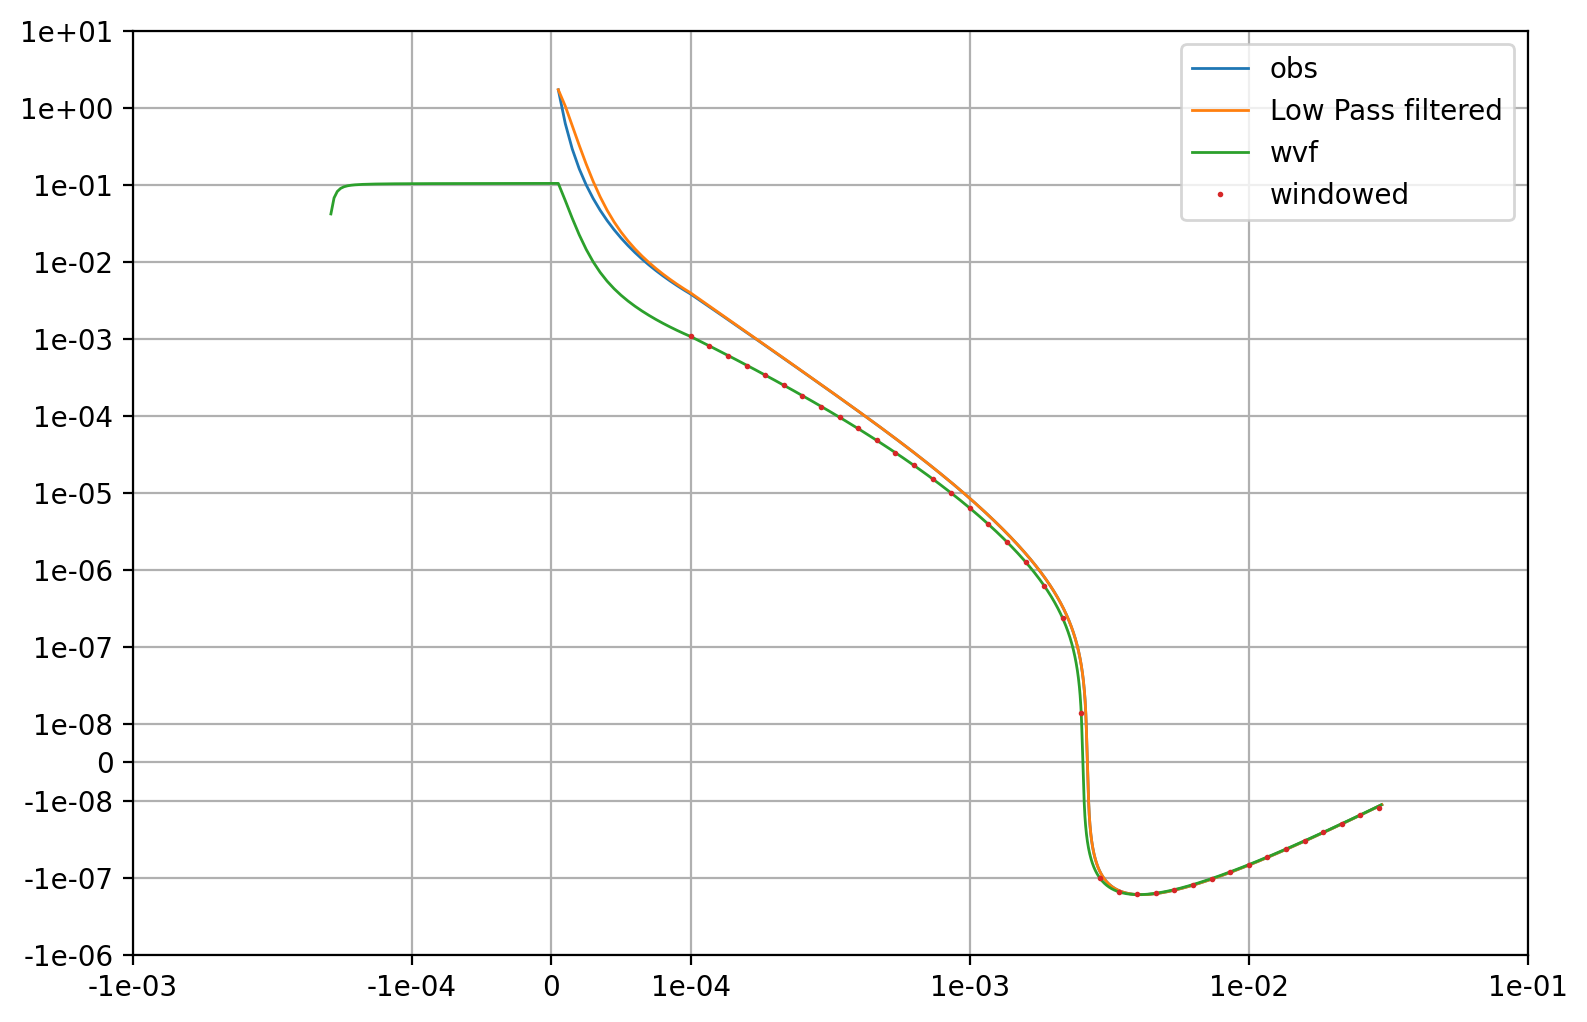

In [16]:
fig, ax= plt.subplots(1,1, figsize=(9,6), dpi=200)

ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_step , linestyle="-",label="obs", color="C0",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc,y=dpred_LPF , linestyle="-",label="Low Pass filtered", color="C1",ax=ax)
ax=PL_decay.plpl_plot(
     x=times_clc-rmp_time,y=dpred_rmp , linestyle="-",label="wvf", color="C2",ax=ax)
ax=PL_decay.plpl_plot(
     x= windows_cen-rmp_time,y=dpred_window , marker="o",linestyle="",label="windowed", color="C3",ax=ax)
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)
#for ax in ax:
ax.grid()
ax.legend()


In [17]:
relative_error=0.05
data_noise_floor = 0.1e-7
dobs_clean =  sim_obs.dpred(mvec_obs)
np.random.seed(0)
# Calculate noise at each point according to the formula
noise_floor = np.random.randn(len(dobs_clean)) * data_noise_floor
noise_relative = np.random.randn(len(dobs_clean)) * relative_error * np.abs(dobs_clean)

# Combine the two sources of noise quadratically (in terms of variance)
total_noise = np.sqrt(noise_floor**2 + noise_relative**2)

# Add the combined noise to the clean data
dobs = dobs_clean + total_noise
# data_init = sim_obs.predicted_data(mvec_ref)

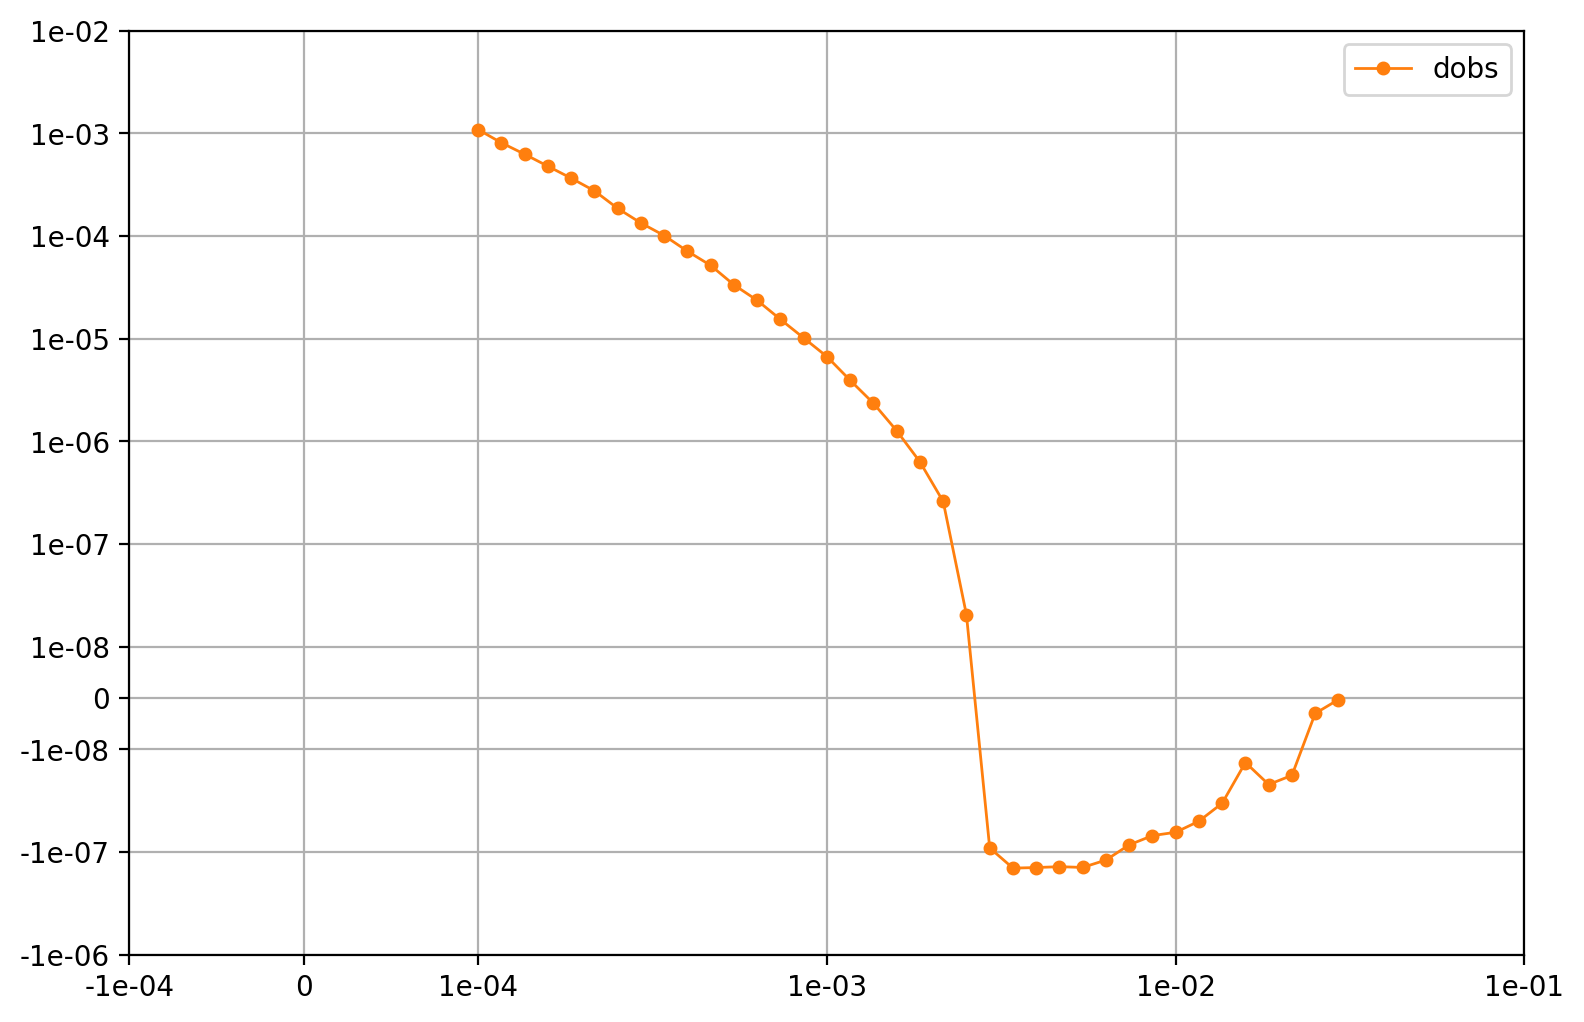

In [18]:
fig, ax= plt.subplots(1,1, figsize=(9,6), dpi=200)
# ax=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=data_init,
#    label="ref/init", color="C0", marker="o",markersize=4,ax=ax
# )
ax=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs, 
   label="dobs", color="C1", marker="o",markersize=4,ax=ax
)
ax= PL_decay.pl_axes(ax)
ax = PL_decay.pl_axes_x(ax)
#for ax in ax:
ax.grid()
ax.legend()


In [19]:
J_pelton = sim_obs.J(mvec_obs)
# J_pelton = sim_obs.J(m_ref1)

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


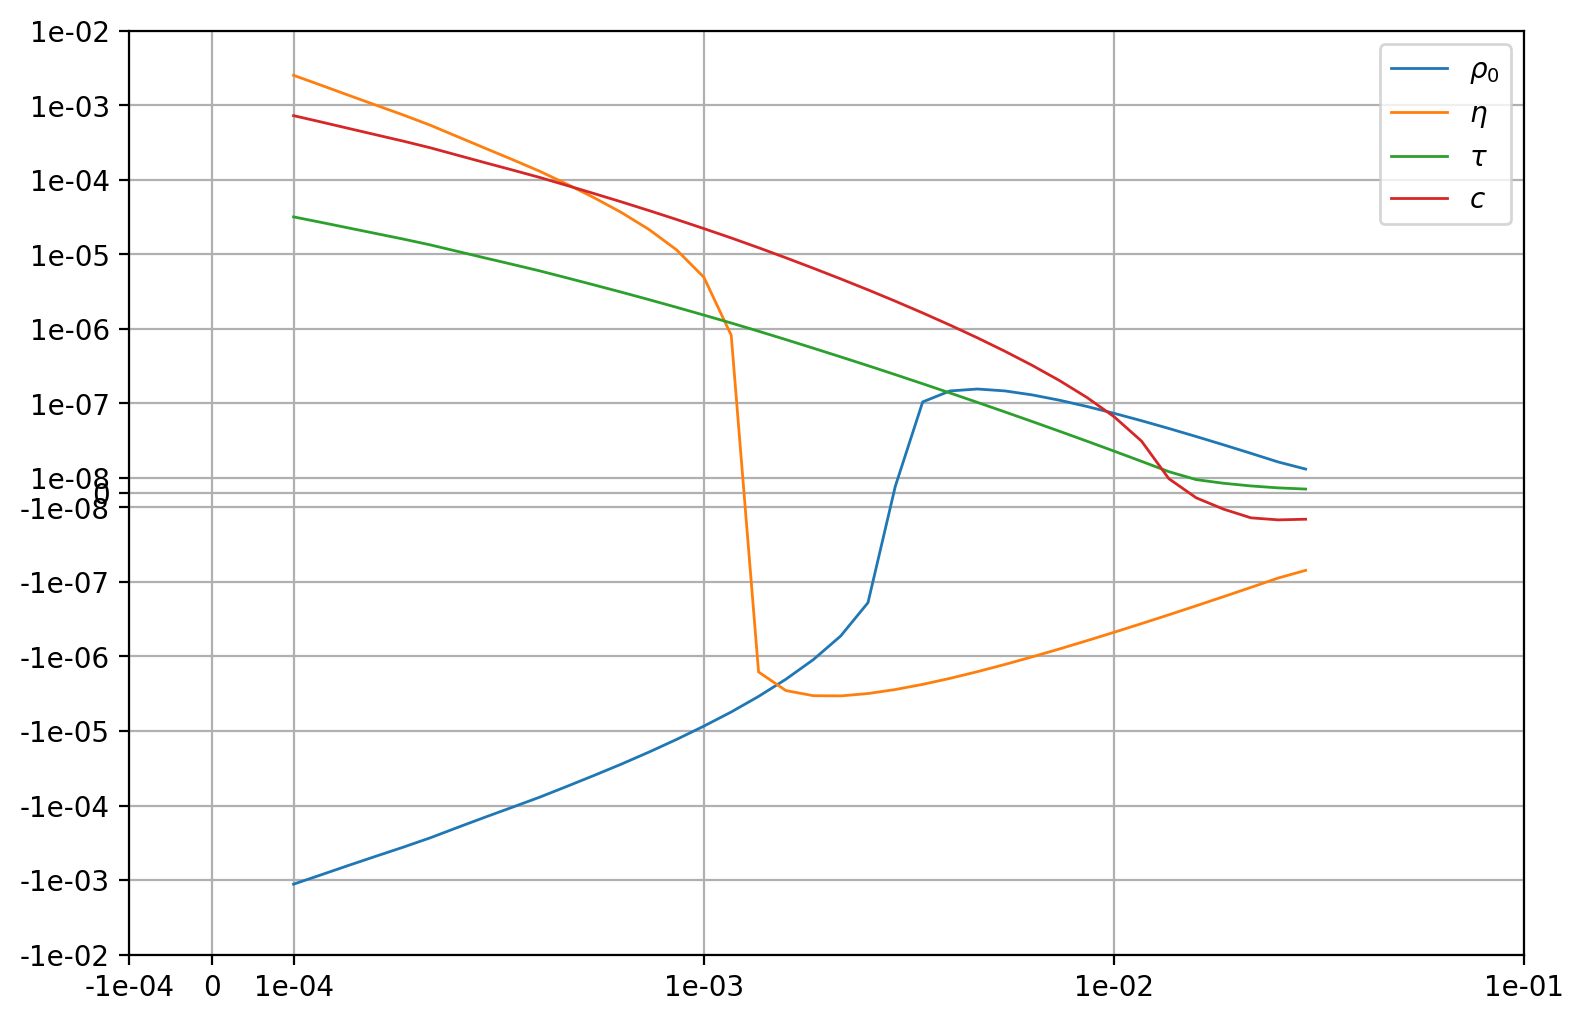

In [20]:
fig, ax= plt.subplots(1,1, figsize=(9,6), dpi=200)

ax=PL_jac.plpl_plot(
     x= windows_cen-rmp_time,y=J_pelton[:,0] ,color=f"C0",
          linestyle="-",label=fr"$\rho_{0}$",ax=ax)
ax =PL_jac.plpl_plot(
     x= windows_cen-rmp_time,y=J_pelton[:,1] ,color=f"C1",
          linestyle="-",label=fr"$\eta$",ax=ax)
ax=PL_jac.plpl_plot(
     x= windows_cen-rmp_time,y=J_pelton[:,2] ,color=f"C2",
          linestyle="-",label=fr"$\tau$",ax=ax)
ax=PL_jac.plpl_plot(
     x= windows_cen-rmp_time,y=J_pelton[:,3] ,color=f"C3",
          linestyle="-",label=fr"$c$",ax=ax)

ax= PL_jac.pl_axes(ax)
ax = PL_jac.pl_axes_x(ax)
#for ax in ax:
ax.grid()
ax.legend()
# plt.savefig("30_TDEM_Pelton_J.jpg", dpi=300)

# Invert with Pelton model

In [21]:
res_ref= res0_target
m_ref1 = np.r_[np.log(res_ref), eta_ref, np.log(tau_target*0.001), c_target]
m_ref2 = np.r_[np.log(res_ref), eta_ref, np.log(tau_target*0.01), c_target]
m_ref3 = np.r_[np.log(res_ref), eta_ref, np.log(tau_target*0.1), c_target]
m_ref4 = np.r_[np.log(res_ref), eta_ref, np.log(tau_target), c_target]
nref= 4
m_refs = [m_ref1, m_ref2, m_ref3, m_ref4]
print(m_refs)

[array([-1.2039728 ,  0.1       , -6.90775528,  0.4       ]), array([-1.2039728 ,  0.1       , -4.60517019,  0.4       ]), array([-1.2039728 ,  0.1       , -2.30258509,  0.4       ]), array([-1.2039728,  0.1      ,  0.       ,  0.4      ])]


In [22]:
# nref=1
# m_ref = np.r_[np.log(res_ref), eta_ref, np.log(tau_target), c_target]
# m_refs = [m_ref]
# print(m_refs)

In [23]:
opt_pelton = Optimization(sim=sim_obs, dobs=dobs, alphas=1.0)
opt_pelton.get_Wd(ratio=relative_error, plateau=noise_floor)
Wd=opt_pelton.Wd
smallness = np.ones(4)
opt_pelton.get_Ws(smallness=smallness)
print(np.diag(opt_pelton.Ws))

[1. 1. 1. 1.]


In [24]:
niter = 50
stol=1e-6
coolingFactor = 2.0
coolingRate = 2
mu=1e-3
beta0_ratio = 1

In [ ]:
models_rec = []
dpreds = []
errors_prg = []
models_prg = []
dinit_refs = []
data_prgs =[]
for i in range(nref):
    m_ref = m_refs[i]
    smallness = np.ones(len(m_ref))
    beta0 = opt_pelton.BetaEstimate_byEig(
        mvec=m_ref, update_Wsen=True, beta0_ratio=beta0_ratio)
    print(beta0)
    mpred = opt_pelton.GaussNewton(
    mvec_init=m_ref,niter=niter,beta0=beta0, update_Wsen=True,
    stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
    )
    
    dinit_refs.append(opt_pelton.dpred(m_ref))
    models_rec.append(mpred)
    dpreds.append(opt_pelton.dpred(mpred))
    errors_prg.append(opt_pelton.error_prg)
    models_prg.append(opt_pelton.mvec_prg)
    data_prgs.append(opt_pelton.data_prg)


1882680165.3875473
  1, beta:1.9e+09, step:1.0e+00, g:1.7e+04, phid:3.7e+03, phim:1.5e-10, f:3.7e+03 
  2, beta:1.9e+09, step:1.0e+00, g:6.0e+00, phid:3.7e+03, phim:1.5e-10, f:3.7e+03 
  3, beta:9.4e+08, step:1.0e+00, g:8.3e+03, phid:3.7e+03, phim:6.0e-10, f:3.7e+03 
  4, beta:9.4e+08, step:1.0e+00, g:6.0e+00, phid:3.7e+03, phim:6.0e-10, f:3.7e+03 
  5, beta:4.7e+08, step:1.0e+00, g:8.3e+03, phid:3.7e+03, phim:2.4e-09, f:3.7e+03 
  6, beta:4.7e+08, step:1.0e+00, g:1.2e+01, phid:3.7e+03, phim:2.4e-09, f:3.7e+03 
  7, beta:2.4e+08, step:1.0e+00, g:8.3e+03, phid:3.7e+03, phim:9.7e-09, f:3.7e+03 
  8, beta:2.4e+08, step:1.0e+00, g:2.4e+01, phid:3.7e+03, phim:9.7e-09, f:3.7e+03 
  9, beta:1.2e+08, step:1.0e+00, g:8.3e+03, phid:3.7e+03, phim:3.9e-08, f:3.7e+03 
 10, beta:1.2e+08, step:1.0e+00, g:4.8e+01, phid:3.7e+03, phim:3.9e-08, f:3.7e+03 
 11, beta:5.9e+07, step:1.0e+00, g:8.3e+03, phid:3.7e+03, phim:1.6e-07, f:3.7e+03 
 12, beta:5.9e+07, step:1.0e+00, g:9.8e+01, phid:3.7e+03, phim:1.6e-

In [ ]:
phid_star=len(windows_cen)
models_rec_phid = []
dpreds_phid = []
phid_star_rtaio = 1.0 # chi factor
phid_itrs = []
for i in range(nref):
    model_prg= np.array(models_prg[i])
    data_prg = np.array(data_prgs[i])
    error_prg = errors_prg[i]
    phid_prg = np.array(error_prg)[:,1]
    ind = phid_prg < phid_star*phid_star_rtaio
    if np.sum(ind) !=0 :
        phid_itr = niter-ind.sum()-1
    if np.sum(ind) == 0:
        ind = phid_prg == np.min(phid_prg)
        phid_itr = np.where(ind)[0][0]
    models_rec_phid.append(model_prg[ind][0])
    dpreds_phid.append(data_prg[ind][0])
    phid_itrs.append(phid_itr)


In [ ]:
print( "Parameter:     res0,   chg,       tau,     c")

for i in range(nref):
    np_mvec_ref = m_refs[i]
    np_mvec_est = models_rec[i]
    m_est_phid = models_rec_phid[i]
    print(f"ref{i+1}     & {np.exp(np_mvec_ref[0]):.2e} & {np_mvec_ref[1]:.3f} & {np.exp(np_mvec_ref[2]):.2e} & {np_mvec_ref[3]:.3f}")
    print(f"est{i+1}     & {np.exp(np_mvec_est[0]):.2e} & { np_mvec_est[1]:.3f} & { np.exp(np_mvec_est[2]):.2e} & { np_mvec_est[3]:.3f}")
    print(f"est_phid{i+1}& {np.exp(m_est_phid[0]):.2e} & { m_est_phid[1]:.3f} & { np.exp(m_est_phid[2]):.2e} & { m_est_phid[3]:.3f}")
print(f"true     & {res0_target:.2e} & {eta_target:.3f} & {tau_target:.2e} & {c_target:.3f}")

Parameter:     res0,   chg,       tau,     c
ref1     & 3.00e-01 & 0.100 & 1.00e-03 & 0.400
est1     & 1.70e-01 & 0.303 & 2.44e-02 & 0.486
est_phid1& 1.53e-01 & 0.174 & 5.54e-03 & 0.666
ref2     & 3.00e-01 & 0.100 & 1.00e-02 & 0.400
est2     & 1.93e-01 & 0.403 & 9.39e-02 & 0.412
est_phid2& 1.61e-01 & 0.177 & 6.23e-03 & 0.689
ref3     & 3.00e-01 & 0.100 & 1.00e-01 & 0.400
est3     & 1.94e-01 & 0.408 & 1.00e-01 & 0.409
est_phid3& 1.79e-01 & 0.259 & 1.62e-02 & 0.601
ref4     & 3.00e-01 & 0.100 & 1.00e+00 & 0.400
est4     & 1.95e-01 & 0.410 & 1.00e-01 & 0.408
est_phid4& 1.95e-01 & 0.383 & 7.99e-02 & 0.425
true     & 3.00e-01 & 0.600 & 1.00e+00 & 0.400


In [ ]:
S_pelton= []
for i in range(nref):
    # jacobian = sim_obs.J(models_rec[i])
    jacobian = sim_obs.J(models_rec_phid[i])
    U, S, V = np.linalg.svd(Wd@jacobian, full_matrices=False)
    s_norm = S/S.max()
    S_pelton.append(s_norm)
print(S_pelton)

[array([1.        , 0.12333365, 0.04052936, 0.00723182]), array([1.        , 0.13548829, 0.0461513 , 0.00734762]), array([1.        , 0.21199744, 0.06140149, 0.0035637 ]), array([1.00000000e+00, 2.85446193e-01, 5.44840194e-02, 8.31228434e-04])]


In [ ]:
# Latex table
# Initialize rows for each parameter
rho_row = "$\\rho_0$"
eta_row = "$\\eta$"
tau_row = "$\\tau$"
c_row   = "$C$"

for i in range(nref):
    np_mvec_ref = m_refs[i]
    # np_mvec_est = models_rec[i]
    np_mvec_est = models_rec_phid[i]
    
    rho_row += f" & {np.exp(np_mvec_ref[0]):.2e} & {np.exp(np_mvec_est[0]):.2e}"
    eta_row += f" & {np_mvec_ref[1]:.3f} & {np_mvec_est[1]:.3f}"
    tau_row += f" & {np.exp(np_mvec_ref[2]):.2e} & {np.exp(np_mvec_est[2]):.2e}"
    c_row   += f" & {np_mvec_ref[3]:.3f} & {np_mvec_est[3]:.3f}"

# Append true values
rho_row += f" & {res0_target:.2e} \\\\"
eta_row += f" & {eta_target:.3f} \\\\"
tau_row += f" & {tau_target:.2e} \\\\"
c_row   += f" & {c_target:.3f} \\\\"

# Print table rows
print(rho_row)
print(eta_row)
print(tau_row)
print(c_row)

$\rho_0$ & 3.00e-01 & 1.53e-01 & 3.00e-01 & 1.61e-01 & 3.00e-01 & 1.79e-01 & 3.00e-01 & 1.95e-01 & 3.00e-01 \\
$\eta$ & 0.100 & 0.174 & 0.100 & 0.177 & 0.100 & 0.259 & 0.100 & 0.383 & 0.600 \\
$\tau$ & 1.00e-03 & 5.54e-03 & 1.00e-02 & 6.23e-03 & 1.00e-01 & 1.62e-02 & 1.00e+00 & 7.99e-02 & 1.00e+00 \\
$C$ & 0.400 & 0.666 & 0.400 & 0.689 & 0.400 & 0.601 & 0.400 & 0.425 & 0.400 \\


Text(0, 0.5, 'EMF (V/A)')

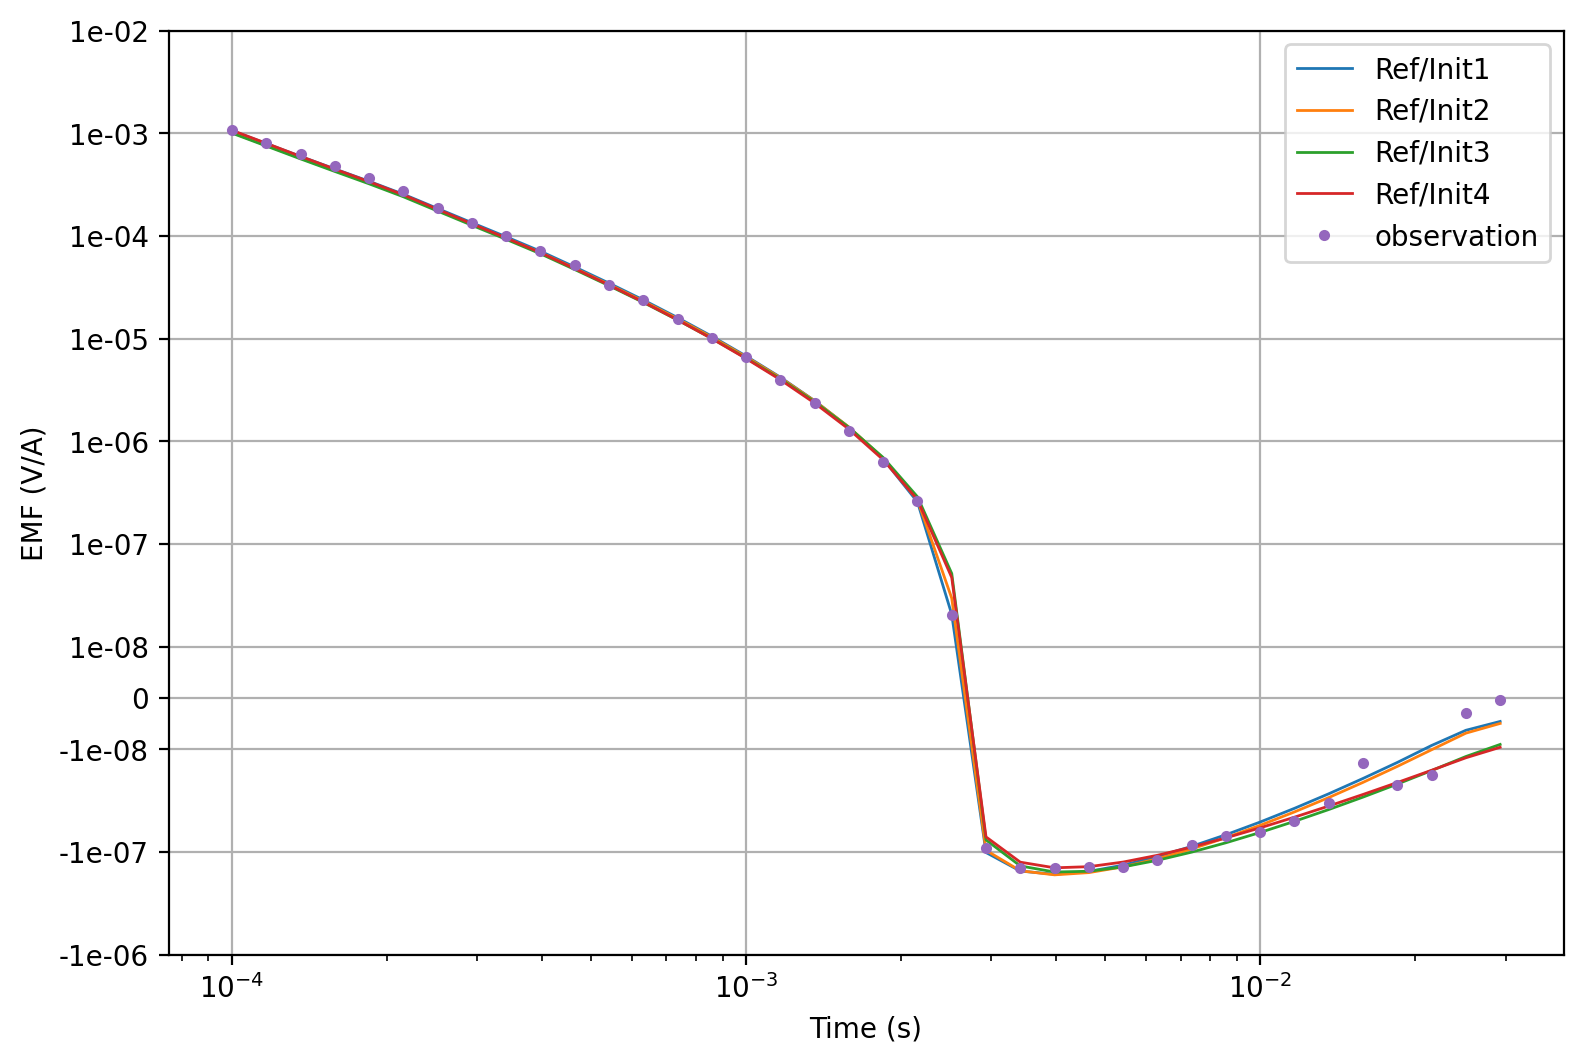

In [ ]:
fig, ax= plt.subplots(1,1, figsize=(9,6), dpi=200)
for i in range(nref):
    # ax=PL_decay.semiply(
    #     windows_cen-rmp_time, dpreds[i], ax=ax,
    #     color=f"C{i}",linestyle="-", label=f"Ref/Init{i+1}"
    #     )
    ax=PL_decay.semiply(
        windows_cen-rmp_time, dpreds_phid[i], ax=ax,
        color=f"C{i}",linestyle="-", label=f"Ref/Init{i+1}"
        )
ax=PL_decay.semiply(
    windows_cen-rmp_time, dobs, ax=ax, marker="o",markersize=3.0,
    color=f"C{nref}",linestyle="", label="observation"
    )
ax = PL_decay.pl_axes(ax)
ax.grid()
ax.legend()
ax.set_xlabel("Time (s)")
ax.set_ylabel("EMF (V/A)")


# Plot Inversion result

In [ ]:
def plot_data(iteration, ax=None):
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
       
    ax=PL_decay.semiply(windows_cen-rmp_time, data_init, ax=ax,
                       color="C1",label="reference"
                       )
    ax=PL_decay.semiply(windows_cen-rmp_time, data_itr[iteration], ax=ax
                        ,color="C0",linestyle="-",
                        label=f"Estimated, iter={iteration}"
                        )
    ax=PL_decay.semiply(windows_cen-rmp_time, dobs, ax=ax, marker="o",markersize=3.0,
                       color="C2",linestyle="", label="observation"
                       )
    ax = PL_decay.pl_axes(ax)
    ax.grid()
    ax.legend()
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EMF (V/A)")
    ax.set_title(f""" Data plot
Relative error {relative_error*100:.1f} %, noise floor {data_noise_floor:.1e} V/A""")
    return ax

In [ ]:
def plot_sip(ax=None):
    if ax is None: 
        fig, ax = plt.subplots(2, 1, figsize=(5,3))

    freq = 10.**np.arange(-1,5.1,0.1)
    ip_model = Pelton_res_f(freq=freq)
    sip_est = ip_model.f(mvec_est)
    sip_obs = ip_model.f(mvec_obs)
    sip_est_abs = np.abs(sip_est)
    sip_est_img = np.angle(sip_est,deg=True)
    sip_obs_abs = np.abs(sip_obs)
    sip_obs_img = np.angle(sip_obs,deg=True)
    ax[0].semilogx(freq, sip_est_abs, color="C0", linestyle="-", label="Estimated")
    ax[0].semilogx(freq, sip_obs_abs, color="C2", linestyle="--", label="True")
    ax[1].semilogx(freq, sip_est_img, color="C0", linestyle="-",label="Estimated")
    ax[1].semilogx(freq, sip_obs_img, color="C2", linestyle="--", label="True")

    ax[0].set_ylim(bottom=0)
    ax[1].invert_yaxis()
    ax[0].set_title(f"SIP of target layer in Absolute Value")
    ax[0].set_ylabel("[Ohm.m]")
    ax[1].set_title(f"SIP of target layer  in Phase [deg]")
    ax[1].set_ylabel("[deg]")


    for a in ax:
        a.grid()
        a.legend()
        a.invert_xaxis()
    return ax

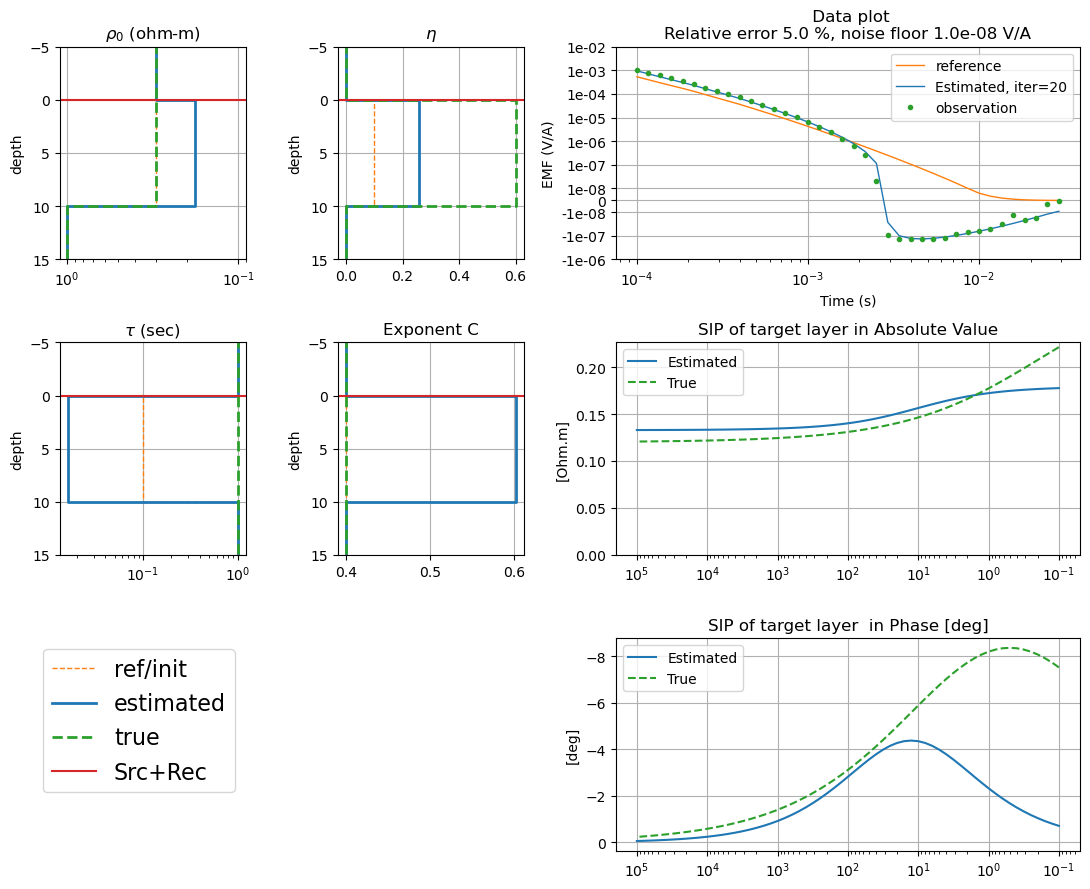

In [ ]:
# fig, axip = plt.subplots(2,2, figsize=(9,6), dpi=200)
# ax = axip.flatten()
ref_id = 2
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(3, 4)  
ax = [None] * 8

ax[0] = fig.add_subplot(gs[0, 0]) #res
ax[1] = fig.add_subplot(gs[0, 1]) #eta
ax[2] = fig.add_subplot(gs[1, 0]) # tau
ax[3] = fig.add_subplot(gs[1, 1]) # expc
ax[4] = fig.add_subplot(gs[2, 0]) # legend
ax[5] = fig.add_subplot(gs[0, 2:]) # data
ax[6] = fig.add_subplot(gs[1, 2:]) #sip_abs
ax[7] = fig.add_subplot(gs[2, 2:]) # sip_img
axm = ax[:4]
axsip =ax[6:]

mvec_ref = m_refs[ref_id]
data_init = dinit_refs[ref_id]
data_itr = data_prgs[ref_id]
mvec_est = models_rec_phid[ref_id]
phid_itr = phid_itrs[ref_id]
#     np_mvec_est = models_rec[i]
# mvec_est = models_rec[i]
axm = sim_obs.plot_IP_par(mvec=mvec_ref,
      label=f"ref/init", color=f"C1", linestyle="--", ax=axm, linewidth=1.0
      )
axm = sim_obs.plot_IP_par(mvec=mvec_est,
        label=f"estimated", color=f"C0", linestyle="-", ax=axm, linewidth=2.0
        )
axm = sim_obs.plot_IP_par(
    mvec=mvec_obs, label="true", color=f"C2", linestyle="--", ax=axm, linewidth=2.0
   )
ax[0].invert_xaxis()
ax[0].set_xlim([1.1,0.09])

ax[5] = plot_data(iteration=phid_itr, ax=ax[5])
axsip = plot_sip(ax=axsip)


for i in range(4):  # Iterate over rows
    ax[i].axhline(empymod_model_sim["src"][4], color=f"C{3}", linestyle="-", label="Src+Rec")
    ax[i].set_ylim([15, -5])
    ax[i].set_ylabel('depth')
    ax[i].grid()
    # ax[i].legend()
    if i== 0 or i ==2:
        ax[i].set_xscale("log")
    else:
        ax[i].set_xscale("linear")
ax[4].axis("off")
handles, labels = ax[0].get_legend_handles_labels()
ax[4].legend(handles, labels, loc='upper right', fontsize=16)

plt.tight_layout()
plt.savefig("30_Pelton.jpg", dpi=300)